<a href="https://colab.research.google.com/github/ansaganakhat/project-1/blob/main/02_shap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Зертханалық жұмыс 2: SHAP (SHapley Additive exPlanations) арқылы модельді түсіндіру


Алдыңғы зертханада біз глобалды feature importance әдістерімен таныстық. Олар модельдің жалпы мінез-құлқын сипаттайды, бірақ жеке болжамды түсіндіруге келгенде әлсіз. Бұл жұмыста біз SHAP әдісімен жұмыс істейміз, ол ойындар теориясындағы Shapley мәндеріне негізделген және әр болжамға әр белгінің нақты қосқан үлесін есептеуге мүмкіндік береді.

## Оқу мақсаттары

Осы зертханалық жұмыстың соңында студент SHAP кітапханасын орнатып, TreeExplainer арқылы ағаш негізіндегі модельдер үшін Shapley мәндерін есептей алатын болады. Сонымен қатар summary plot, waterfall plot, bar plot және dependence plot графиктерін салып, олардың мазмұнын дұрыс интерпретациялай алады. Ең бастысы, глобалды және локалды түсіндірудің айырмашылығын нақты мысал арқылы сезіне алады.

## Жұмыс құрылымы

1-бөлім. Ортаны дайындау, SHAP кітапханасын орнату.
2-бөлім. Adult Income деректер жинағын жүктеу және дайындау.
3-бөлім. Gradient Boosting моделін оқыту.
4-бөлім. SHAP TreeExplainer инициализациясы және Shapley мәндерін есептеу.
5-бөлім. Глобалды түсіндіру: summary plot және bar plot.
6-бөлім. Локалды түсіндіру: waterfall plot нақты бір жолаушы үшін.
7-бөлім. Dependence plot арқылы белгілер арасындағы өзара әсерді талдау.
8-бөлім. Рефлексия сұрақтары.

## 1-бөлім. Ортаны дайындау

SHAP кітапханасы pip арқылы оңай орнатылады. IBM Skills Network ортасында ол алдын ала орнатылмаған болуы мүмкін, сондықтан төмендегі жолды бірінші рет іске қосыңыз.

In [29]:
# SHAP кітапханасын орнат
!pip install shap --quiet

In [30]:
# Негізгі кітапханалар
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# Кездейсоқтықты бекітеміз
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# SHAP визуализацияларын Jupyter-де көрсету үшін
shap.initjs()

# SHAP нұсқасын тексереміз
print("SHAP нұсқасы:", shap.__version__)

SHAP нұсқасы: 0.52.0


## 2-бөлім. Деректерді жүктеу

Бұл жұмыста Adult Income (Census Income) деректер жинағын пайдаланамыз. Мақсат — адамның жылдық табысы 50 мың доллардан асатын-аспайтынын анықтау. Бұл әлеуметтік маңызы бар классификация есебі, сондықтан модельдің шешімін түсіндіру аса маңызды.

In [31]:
# Adult деректер жинағын жүктеу
adult = fetch_openml("adult", version=2, as_frame=True)
df = adult.frame.copy()

# Кестенің басы
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


### ### TODO ###

Деректердің құрылымын түсіну үшін төмендегі қадамдарды орындаңыз.

In [32]:
### ### TODO ###
# 1. Деректердің өлшемін шығарыңыз
# print("Форма:", df.____)
print("Форма:", df.shape)
print("\nМақсатты айнымалының саны:")


# 2. Мақсатты айнымалы 'class' бойынша үлестірімді көрсетіңіз
# print(df["class"].____())
print(df["class"].value_counts())
print("\nМақсатты айнымалының үлесі:")
# 3. Бос мәндер бар-жоғын тексеріңіз
# print(df.____.sum())
print(df.isnull().sum().sort_values(ascending=False))
print(df["class"].value_counts(normalize=True).round(4))
print("\nБос мәндер саны:")

Форма: (48842, 15)

Мақсатты айнымалының саны:
class
<=50K    37155
>50K     11687
Name: count, dtype: int64

Мақсатты айнымалының үлесі:
occupation        2809
workclass         2799
native-country     857
fnlwgt               0
education            0
education-num        0
age                  0
marital-status       0
relationship         0
sex                  0
race                 0
capital-gain         0
capital-loss         0
hours-per-week       0
class                0
dtype: int64
class
<=50K    0.7607
>50K     0.2393
Name: proportion, dtype: float64

Бос мәндер саны:


In [33]:
# Деректерді дайындау: категориялық бағандарды one-hot encoding арқылы кодтаймыз
# Есептеу жеңіл болу үшін негізгі белгілерді таңдап аламыз
selected_cols = [
    "age", "education-num", "hours-per-week",
    "capital-gain", "capital-loss",
    "workclass", "marital-status", "occupation", "sex",
    "class"
]
df = df[selected_cols].dropna().copy()

# Категориялық бағандар
cat_cols = ["workclass", "marital-status", "occupation", "sex"]

# One-hot encoding
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Мақсатты айнымалыны 0/1 түріне келтіреміз
df_encoded["class"] = (df_encoded["class"] == ">50K").astype(int)

y = df_encoded["class"]
X = df_encoded.drop(columns=["class"])

print("Белгі саны:", X.shape[1])
X.head()

Белгі саны: 32


,age,education-num,hours-per-week,capital-gain,capital-loss,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,sex_Male
0,25,7,40,0,0,False,False,True,False,False,...,False,True,False,False,False,False,False,False,False,True
1,38,9,50,0,0,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
2,28,12,40,0,0,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
3,44,10,40,7688,0,False,False,True,False,False,...,False,True,False,False,False,False,False,False,False,True
5,34,6,30,0,0,False,False,True,False,False,...,False,False,True,False,False,False,False,False,False,True


### ### TODO ###

Деректерді оқу және тест жиынтықтарына бөліңіз. Тест үлесі 25%, стратификация мақсатты айнымалы бойынша жүргізілсін.

In [34]:
### ### TODO ###
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y,
#     test_size=____,
#     stratify=____,
#     random_state=RANDOM_STATE
# )
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Оқу:", X_train.shape, "Тест:", X_test.shape)
print("Тест target үлесі:")
print(y_test.value_counts(normalize=True).round(4))
# print("Оқу:", X_train.shape, "Тест:", X_test.shape)

Оқу: (34524, 32) Тест: (11509, 32)
Тест target үлесі:
class
0    0.7518
1    0.2482
Name: proportion, dtype: float64


## 3-бөлім. Модельді оқыту

Gradient Boosting классификаторы ағаш негізіндегі модель болғандықтан, оған SHAP TreeExplainer тікелей қолданылады. Бұл — SHAP-тың ең жылдам және дәл нұсқасы.

### ### TODO ###

Gradient Boosting моделін оқытыңыз. Ағаштар саны 200, оқу қадамы (learning_rate) 0.1, максималды тереңдігі 3 болсын.

In [35]:
### ### TODO ###
# gb_model = GradientBoostingClassifier(
#     n_estimators=____,
#     learning_rate=____,
#     max_depth=____,
#     random_state=RANDOM_STATE
# )

# gb_model.fit(____, ____)

# Тест жиынтығында бағалау
# y_pred = gb_model.predict(X_test)
# y_proba = gb_model.predict_proba(X_test)[:, 1]

# print(f"Дәлдік: {accuracy_score(y_test, y_pred):.4f}")
# print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE
)

gb_model.fit(X_train, y_train)

y_pred = gb_model.predict(X_test)
y_proba = gb_model.predict_proba(X_test)[:, 1]

print(f"Дәлдік: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")

Дәлдік: 0.8666
ROC AUC: 0.9222


## 4-бөлім. SHAP TreeExplainer

Shapley мәні әр белгі үшін модель болжамының базалық мәннен қаншалықты алшақтауына қосқан үлесін көрсетеді. Ағаш моделі үшін бұл есептеу TreeSHAP алгоритмі арқылы полиномиалды уақытта орындалады. Есептеу қорына сақтандыру мақсатында тест жиынтығының алғашқы 500 мысалын аламыз.

In [36]:
# Есептеуді жеңілдету үшін тест жиынтығының үлгісін алу
X_sample = X_test.iloc[:500].copy()

# SHAP TreeExplainer инициализациясы
explainer = shap.TreeExplainer(gb_model)

# Shapley мәндерін есептеу
shap_values = explainer.shap_values(X_sample)

# Пішінін тексереміз: (үлгі саны, белгі саны)
print("SHAP массивінің пішіні:", np.array(shap_values).shape)
print("Базалық мән (expected_value):", explainer.expected_value)

SHAP массивінің пішіні: (500, 32)
Базалық мән (expected_value): [-1.99284452]


## 5-бөлім. Глобалды түсіндіру

Ең алдымен модельдің жалпы мінез-құлқын қарастырамыз. SHAP summary plot әр белгіні маңыздылығы бойынша реттеп, әр нүктені (бір мысалды) Shapley мәні бойынша орналастырады. Түс белгінің нақты мәнін көрсетеді: қызыл — жоғары, көк — төмен.

/tmp/ipykernel_3369/1289551445.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, show=True)


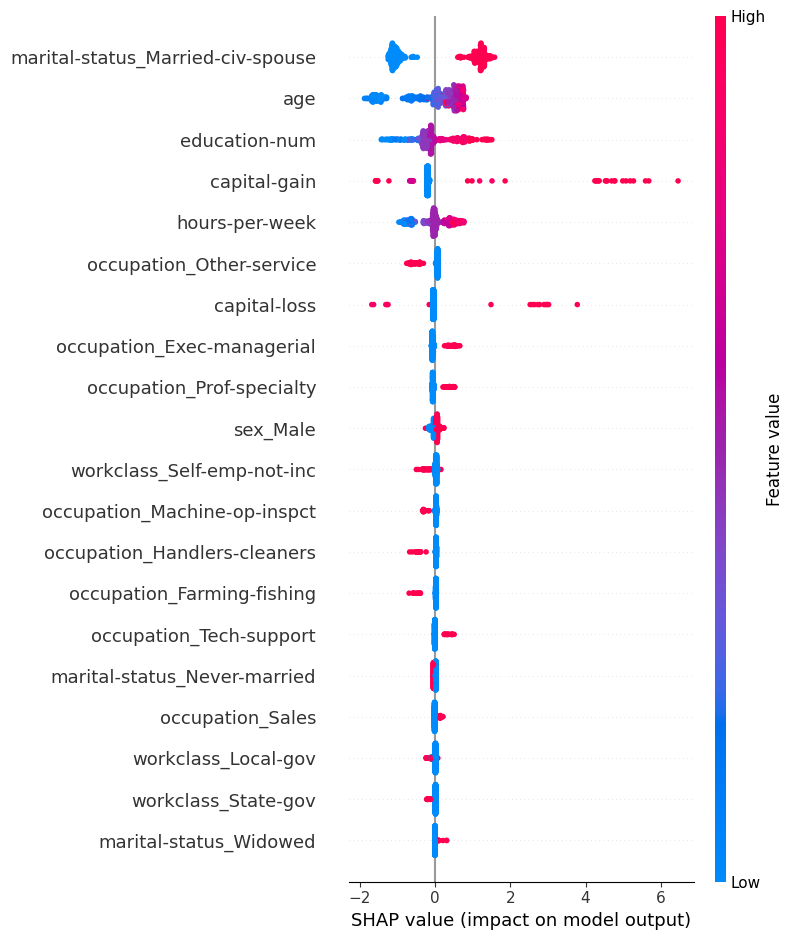

In [37]:
# Summary plot: белгілердің таралуы мен әсер бағыты
shap.summary_plot(shap_values, X_sample, show=True)

### ### TODO ###

Тек орташа абсолютті Shapley мәнін көрсететін bar plot салыңыз. Бұл — глобалды feature importance-тың SHAP нұсқасы.

/tmp/ipykernel_3369/123949378.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


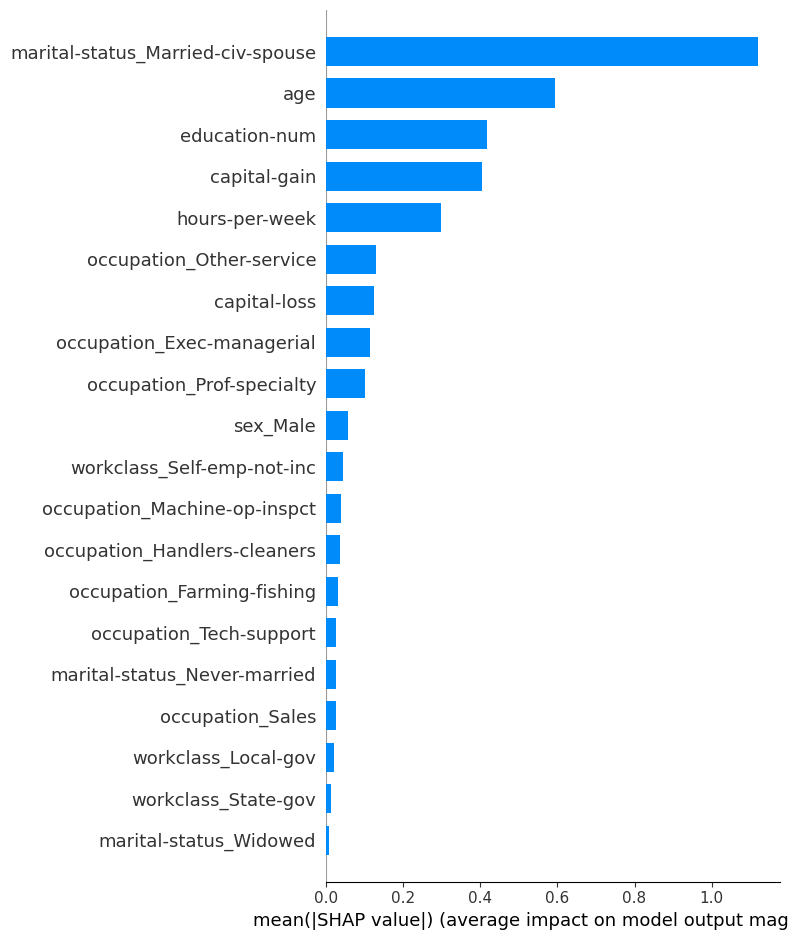

In [38]:
### ### TODO ###
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar",
    show=True
)

In [39]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "feature": X_sample.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

display(shap_importance_df.head(10))

,feature,mean_abs_shap
0,marital-status_Married-civ-spouse,1.120922
1,age,0.594238
2,education-num,0.416715
3,capital-gain,0.404982
4,hours-per-week,0.297545
5,occupation_Other-service,0.130025
6,capital-loss,0.124059
7,occupation_Exec-managerial,0.113500
8,occupation_Prof-specialty,0.102662
9,sex_Male,0.057310


**Талдау сұрағы 1.** Summary plot графигіне қарап, ең үлкен әсер ететін үш белгіні атаңыз. Олардың жоғары мәні болжамды жоғары табыс жағына (>50K) қарай жылжыта ма, әлде керісінше? Бір абзацпен түсіндіріңіз.

Ең маңызды үш белгі жоғарыдағы кестенің алғашқы үш жолында көрсетіледі. Жоғары `capital-gain`, `education-num`, `age` және `hours-per-week` мәндері көбіне болжамды `>50K` жағына жылжытады. Төмен мәндер кері бағытта әсер етеді. One-hot категориялардың бағыты олардың нақты мағынасына байланысты.

## 6-бөлім. Локалды түсіндіру

Енді SHAP-тың ең күшті мүмкіндігіне келеміз — жеке болжамды түсіндіру. Тест жиынтығынан бір нақты мысалды таңдап алып, модельдің неге дәл осы болжам бергенін көрсететін waterfall plot салайық.

In [40]:
# Тексеретін мысалды таңдау
idx = 0

# Осы мысал үшін модельдің болжамын көру
prob = gb_model.predict_proba(X_sample.iloc[[idx]])[0, 1]
print(f"№{idx} мысал үшін >50K табыстың ықтималдығы: {prob:.4f}")
print(f"Нақты таңба: {y_test.iloc[idx]}")

№0 мысал үшін >50K табыстың ықтималдығы: 0.0030
Нақты таңба: 0


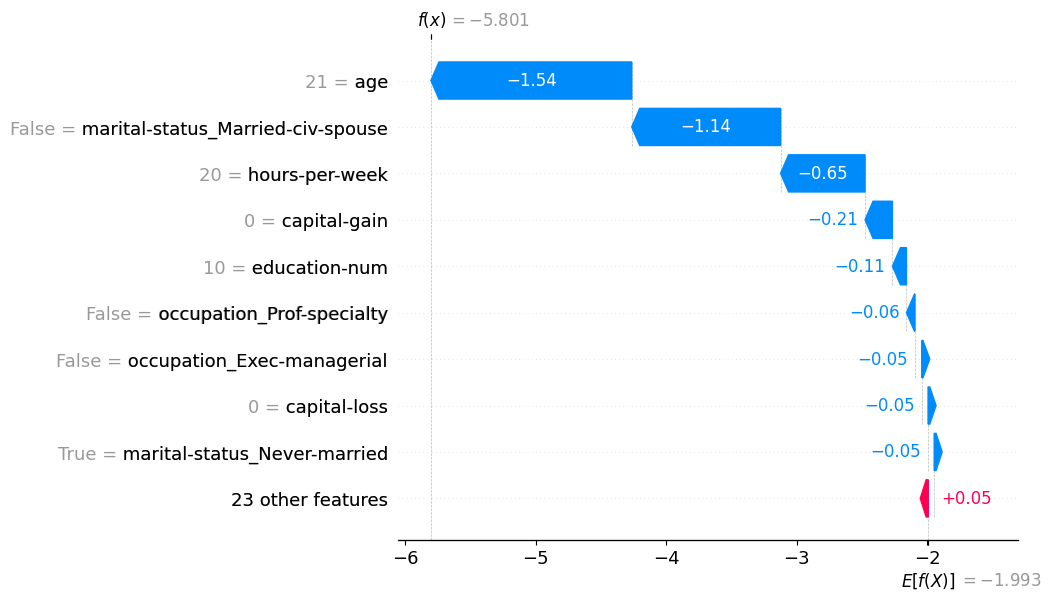

In [41]:
# Waterfall plot: жеке болжам үшін әр белгінің үлесі
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_sample.iloc[idx],
        feature_names=X_sample.columns.tolist()
    ),
    show=True
)

### ### TODO ###

Жоғарыдағы кодты бейімдеп, тест жиынтығындағы басқа мысалды (мысалы, idx=25) талдаңыз. Егер модельдің болжамы >0.5 болса, қай белгілер оң үлес қосты, ал <0.5 болса, қай белгілер теріс үлес қосты — соны атап көрсетіңіз.

№25 мысал үшін ықтималдық: 0.0032
Болжанған класс: 0
Нақты класс: 0
Базалық мән E[f(x)]: -1.9928


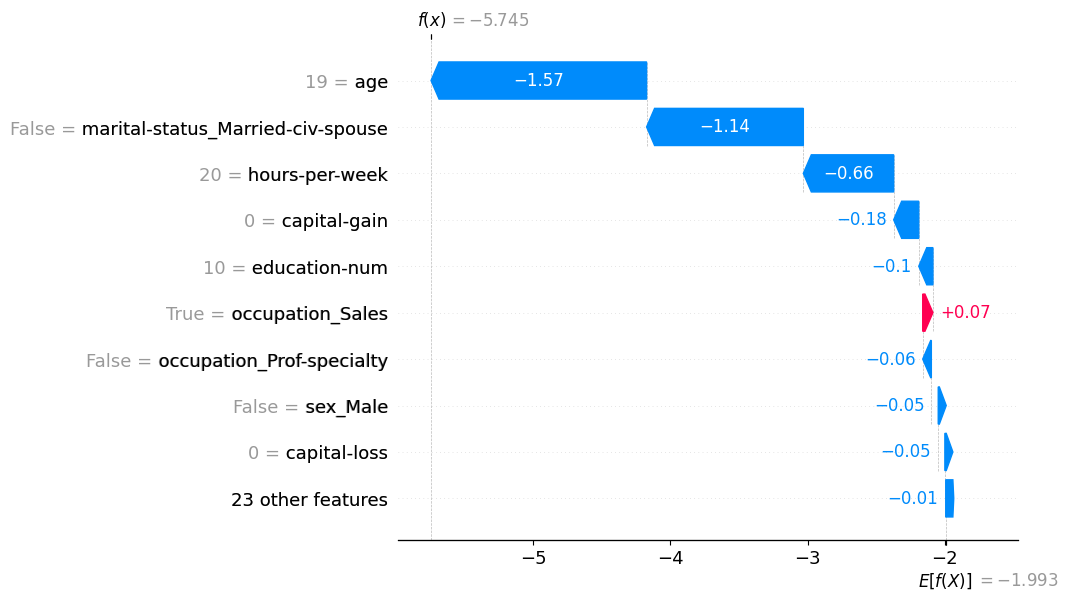

In [42]:
### ### TODO ###
# expected_value кейбір SHAP нұсқаларында массив болып қайтады
base_value = float(
    np.asarray(explainer.expected_value).reshape(-1)[0]
)

idx2 = 25

prob2 = gb_model.predict_proba(
    X_sample.iloc[[idx2]]
)[0, 1]

print(f"№{idx2} мысал үшін ықтималдық: {prob2:.4f}")
print(f"Болжанған класс: {int(prob2 >= 0.5)}")
print(f"Нақты класс: {int(y_test.iloc[idx2])}")
print(f"Базалық мән E[f(x)]: {base_value:.4f}")

shap.plots.waterfall(
    shap.Explanation(
        values=np.asarray(shap_values[idx2]),
        base_values=base_value,
        data=X_sample.iloc[idx2].to_numpy(),
        feature_names=X_sample.columns.tolist()
    ),
    show=True
)

In [43]:
local_explanation_df = pd.DataFrame({
    "feature": X_sample.columns,
    "feature_value": X_sample.iloc[idx2].values,
    "shap_value": shap_values[idx2]
})
local_explanation_df["abs_shap"] = local_explanation_df["shap_value"].abs()
local_explanation_df = local_explanation_df.sort_values("abs_shap", ascending=False)

print("Оң үлес қосқан белгілер:")
display(local_explanation_df[local_explanation_df["shap_value"] > 0].head(10))
print("Теріс үлес қосқан белгілер:")
display(local_explanation_df[local_explanation_df["shap_value"] < 0].head(10))

Оң үлес қосқан белгілер:


,feature,feature_value,shap_value,abs_shap
28,occupation_Sales,True,0.074434,0.074434
24,occupation_Other-service,False,0.044389,0.044389
22,occupation_Handlers-cleaners,False,0.016934,0.016934
21,occupation_Farming-fishing,False,0.014254,0.014254
23,occupation_Machine-op-inspct,False,0.013058,0.013058
5,workclass_Local-gov,False,0.006349,0.006349
10,workclass_State-gov,False,0.006153,0.006153
9,workclass_Self-emp-not-inc,False,0.003770,0.003770
16,marital-status_Separated,False,0.003119,0.003119
27,occupation_Protective-serv,False,0.001930,0.001930


Теріс үлес қосқан белгілер:


,feature,feature_value,shap_value,abs_shap
0,age,19,-1.571251,1.571251
13,marital-status_Married-civ-spouse,False,-1.142615,1.142615
2,hours-per-week,20,-0.658589,0.658589
3,capital-gain,0,-0.182887,0.182887
1,education-num,10,-0.103212,0.103212
26,occupation_Prof-specialty,False,-0.062899,0.062899
31,sex_Male,False,-0.050235,0.050235
4,capital-loss,0,-0.048371,0.048371
20,occupation_Exec-managerial,False,-0.048141,0.048141
15,marital-status_Never-married,True,-0.046889,0.046889


**Талдау сұрағы 2.** Waterfall plot-тағы f(x) мәні мен E[f(x)] мәні нені білдіреді? Олардың арасындағы айырма қалай интерпретацияланады? Екі-үш сөйлеммен жазыңыз.

## 7-бөлім. Dependence plot

Dependence plot бір белгінің мәні мен оның Shapley мәні арасындағы байланысты көрсетеді. Сонымен қатар автоматты түрде екінші бір белгіні түс арқылы бейнелеп, өзара әсерді (interaction) көруге көмектеседі. Мұны age белгісі мысалында тексеріп көрейік.

`E[f(x)]` — модельдің орташа базалық шығысы, ал `f(x)` — нақты мысал үшін модель шығысы. Айырмасы барлық SHAP үлестерінің қосындысына тең. Бұл модельде waterfall мәндері әдетте log-odds шкаласында болады.

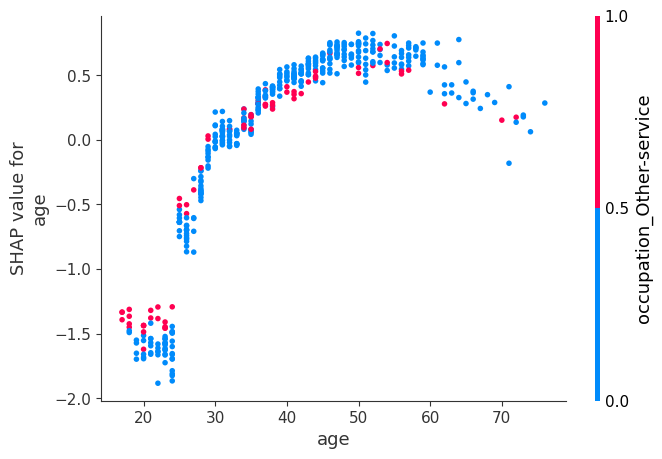

In [44]:
# age белгісінің Shapley мәнге әсері
shap.dependence_plot(
    "age",
    shap_values,
    X_sample,
    interaction_index="auto",
    show=True
)

### ### TODO ###

Hours-per-week белгісі үшін dependence plot салыңыз. Interaction белгісі ретінде education-num таңдаңыз.

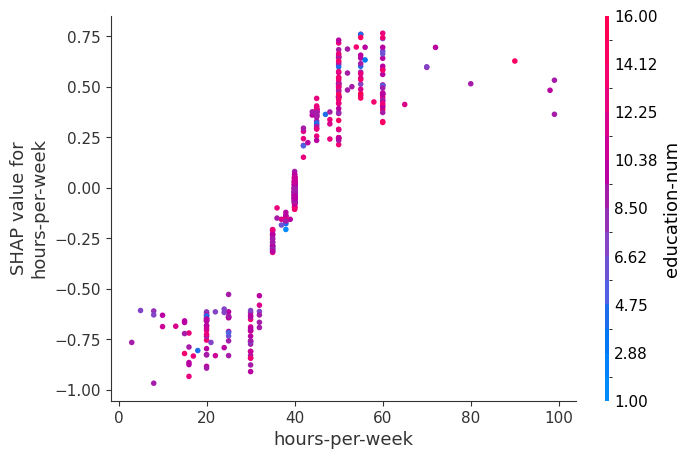

In [45]:
### ### TODO ###
shap.dependence_plot(
    "hours-per-week",
    shap_values,
    X_sample,
    interaction_index="education-num",
    show=True
)

**Талдау сұрағы 3.** Hours-per-week пен education-num арасында айтарлықтай өзара әсер бар ма? Мысалы, білім деңгейі жоғары адамдар үшін сағат санының әсері білім деңгейі төмен адамдармен салыстырғанда өзгеше ме? Графикке сүйене отырып сипаттаңыз.

Бірдей жұмыс сағатында білім деңгейі жоғары нүктелердің SHAP мәні жоғарырақ болса, `hours-per-week` және `education-num` арасында өзара әсер бар. Бұл жағдайда жоғары білім көп жұмыс сағатының оң әсерін күшейтеді. Түстер біркелкі араласып тұрса, өзара әсер әлсіз.

## 8-бөлім. SHAP әдісінің практикалық аспектілері

SHAP әсіресе өнеркәсіптік қолданыста өте пайдалы, бірақ бірнеше ескертпені есте ұстау керек. Біріншіден, TreeExplainer тек ағаш моделдеріне арналған; нейрондық желілер үшін DeepExplainer немесе GradientExplainer, ал кез келген модель үшін KernelExplainer қолданылады, бірақ соңғысы едәуір баяу жұмыс істейді. Екіншіден, SHAP мәндері шартты күтім (conditional expectation) арқылы есептелетіндіктен, өзара тәуелді белгілер жағдайында интерпретация күрделене түседі. Үшіншіден, SHAP себеп-салдарлық байланысты дәлелдемейді — ол тек модельдің мінез-құлқын түсіндіреді, шынайы себептерді емес.

### ### TODO ###

Модель мен түсіндіру жүйесін салыстыру үшін алдыңғы зертханадағы permutation importance-ты дәл осы деректерге қолданыңыз. Кейін нәтижелерді SHAP bar plot-пен салыстырыңыз.

In [46]:
### ### TODO ###
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    gb_model, X_test, y_test,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="accuracy",
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "perm_importance": perm.importances_mean,
    "perm_std": perm.importances_std
}).sort_values("perm_importance", ascending=False).reset_index(drop=True)

display(perm_df.head(10))

,feature,perm_importance,perm_std
0,marital-status_Married-civ-spouse,0.056808,0.003092
1,capital-gain,0.047128,0.000904
2,education-num,0.032062,0.001602
3,age,0.017830,0.001357
4,capital-loss,0.014441,0.000575
5,hours-per-week,0.007107,0.000660
6,occupation_Exec-managerial,0.005005,0.000551
7,occupation_Tech-support,0.001703,0.000328
8,workclass_Self-emp-not-inc,0.001634,0.000177
9,occupation_Other-service,0.001634,0.000115


In [47]:
comparison_df = shap_importance_df.merge(perm_df, on="feature", how="inner")
comparison_df["SHAP_rank"] = comparison_df["mean_abs_shap"].rank(ascending=False, method="min").astype(int)
comparison_df["Permutation_rank"] = comparison_df["perm_importance"].rank(ascending=False, method="min").astype(int)
comparison_df["rank_difference"] = (
    comparison_df["SHAP_rank"] - comparison_df["Permutation_rank"]
).abs()

comparison_df = comparison_df.sort_values("SHAP_rank")
display(comparison_df.head(15))

,feature,mean_abs_shap,perm_importance,perm_std,SHAP_rank,Permutation_rank,rank_difference
0,marital-status_Married-civ-spouse,1.120922,0.056808,0.003092,1,1,0
1,age,0.594238,0.017830,0.001357,2,4,2
2,education-num,0.416715,0.032062,0.001602,3,3,0
3,capital-gain,0.404982,0.047128,0.000904,4,2,2
4,hours-per-week,0.297545,0.007107,0.000660,5,6,1
5,occupation_Other-service,0.130025,0.001634,0.000115,6,9,3
6,capital-loss,0.124059,0.014441,0.000575,7,5,2
7,occupation_Exec-managerial,0.113500,0.005005,0.000551,8,7,1
8,occupation_Prof-specialty,0.102662,0.001494,0.000681,9,11,2
9,sex_Male,0.057310,0.001338,0.000231,10,13,3


**Талдау сұрағы 4.** SHAP bar plot және permutation importance ұқсас реттілік беріп тұр ма? Ұқсамаған жағдайда, олардың теориялық негіздері арасындағы қандай айырмашылық мұны түсіндіреді?

Екі әдіс кей белгілер бойынша ұқсас реттілік беруі мүмкін, бірақ толық сәйкес болмауы қалыпты. SHAP болжамға қосылған үлесті өлшейді; permutation importance белгіні араластырғандағы метрика төмендеуін өлшейді. Корреляцияланған белгілерде осы айырмашылық анық байқалады.

## Қорытынды

Осы жұмыста сіз SHAP әдісін нақты классификация есебіне қолданып, глобалды және локалды түсіндіру арасындағы айырмашылықты өз көзіңізбен көрдіңіз. Summary plot модельдің жалпы логикасын, waterfall plot нақты бір шешімнің механизмін, ал dependence plot белгілер арасындағы өзара әсерді ашады. SHAP әсіресе банк секторында (несиеге рұқсат беру), медицинада (диагноз қою) және басқа да жоғары жауапкершілік талап ететін салаларда қолданылады. Келесі зертханада біз тағы бір локалды түсіндіру әдісі — LIME-мен танысамыз және оны SHAP-пен салыстырамыз.

## Рефлексия сұрақтары

1. SHAP мәндерінің қосындысы модель болжамы мен базалық мәннің айырмасына тең. Бұл қасиет практикада неге маңызды? Мысал келтіріңіз.

Additivity қасиеті базалық мән мен барлық үлестердің қосындысы нақты модель шығысына тең болуын қамтамасыз етеді. Бұл түсіндірудің толық және тексерілетін болуына қажет.

2. Егер сіз банк маманы болып, несие беруден бас тартылған клиентке шешімді түсіндіруіңіз керек болса, SHAP-тың қандай визуализациясын пайдаланар едіңіз және неге?

Бір клиенттің несие шешімін түсіндіру үшін waterfall plot тиімді, себебі ол әр фактордың оң және теріс үлесін көрсетеді.

3. TreeExplainer, KernelExplainer және DeepExplainer арасындағы негізгі айырмашылық қандай? Қай жағдайда қайсысын таңдаған дұрыс?

TreeExplainer — ағаш модельдеріне жылдам әрі дәл; KernelExplainer — кез келген модельге, бірақ баяу; DeepExplainer — нейрондық желілерге арналған.
